# W&B Sweep — PPO
Búsqueda de hiperparámetros para el agente DQN en el ambiente Simple (CSTR).
- Método: Random Search
- Proyecto W&B: `Tesis_PPO_CTRL`
- Arquitectura: simple (solo CTRL)

## 1. Instalación e Imports

In [1]:
import os
import random
import numpy as np
import torch
import wandb
import sys
import pandas as pd
import matplotlib.pyplot as plt
import types

ModuleNotFoundError: No module named 'wandb'

In [2]:
# Clonar desde Github:
!git clone https://github.com/valeriaeskenazi/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning.git
PROJECT_PATH = '/content/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning/Version_4'
sys.path.append(PROJECT_PATH)

Cloning into 'Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning'...
remote: Enumerating objects: 1482, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 1482 (delta 18), reused 33 (delta 12), pack-reused 1440 (from 1)
Receiving objects: 100% (1482/1482), 34.27 MiB | 21.41 MiB/s, done.
Resolving deltas: 100% (882/882), done.


In [3]:
from Environment.Simulation_Env.Reactor_CSTR import CSTRSimulator
from Environment.PIDControlEnv_simple import PIDControlEnv_Simple
from Environment.PIDControlEnv_complex import PIDControlEnv_Complex
from Agente.PPO.train_PPO import PPOTrainer
from Agente.PPO.algorithm_PPO import PPOAgent
from Aux.Plots import SimplePlotter, print_summary

print('Imports completados')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {"CUDA" if torch.cuda.is_available() else "CPU"}')

Imports completados
PyTorch: 2.10.0+cpu
Device: CPU


In [4]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

/bin/bash: line 1: nvidia-smi: command not found


## 2. Login W&B

In [5]:
!pip install wandb --quiet

In [6]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ve326684 (ve326684-universidad-ort-uruguay) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 3. Configuración del Sweep

In [8]:
# ============ LISTAS DE OPCIONES PREDEFINIDAS ============

REWARD_WEIGHTS_OPTIONS = [
    {'error': 1.0, 'tiempo': 0.3,   'overshoot': 0.2,  'energy': 0.1},    # 0: balanceado
    {'error': 2.0, 'tiempo': 0.1,   'overshoot': 0.5,  'energy': 0.1},    # 1: foco en error y overshoot
    {'error': 1.0, 'tiempo': 0.001, 'overshoot': 0.3,  'energy': 0.001},  # 2: tu config base PPO
    {'error': 3.0, 'tiempo': 0.1,   'overshoot': 0.1,  'energy': 0.05},   # 3: solo error importa
]

HIDDEN_DIMS_OPTIONS = [
    (64, 32),
    (128, 64),
    (128, 128, 64),
    (256, 128, 64),
]

# ============ FIJOS PARA TODOS LOS RUNS ============
SEED             = 42
N_EPISODES       = 300
EVAL_FREQUENCY   = 50
EARLY_STOPPING_PATIENCE      = 10
EARLY_STOPPING_MIN_DELTA_PCT = 0.01
N_MANIPULABLE_VARS  = 2
MANIPULABLE_RANGES  = [(300, 420), (99.5, 104)]
DT                  = 1.0
DEVICE              = 'cuda' if torch.cuda.is_available() else 'cpu'

WANDB_TEAM    = 've326684-universidad-ort-uruguay'
WANDB_PROJECT = 'Tesis_PPO_CTRL'

sweep_config = {
    'name':   'ppo_cstr_random_search',
    'method': 'random',

    'metric': {
        'name': 'eval_reward',
        'goal': 'maximize'
    },

    'parameters': {

        # ============ AMBIENTE ============
        'max_time_detector':  {'values': [15, 30, 60]},
        'max_steps':          {'values': [20, 50, 100]},
        'reward_dead_band':   {'values': [0.01, 0.02, 0.05]},
        'delta_percent_ctrl': {'values': [0.05, 0.1, 0.2, 0.3]},
        'reward_weights_idx': {'values': [0, 1, 2, 3]},

        # ============ CRITERIOS DE ESTABILIDAD ============
        'error_increase_tolerance': {'values': [1.2, 1.5, 2.0]},
        'max_sign_changes_ratio':   {'values': [0.1, 0.2, 0.3]},
        'max_abrupt_change_ratio':  {'values': [0.03, 0.05, 0.1]},
        'abrupt_change_threshold':  {'values': [0.2, 0.3, 0.5]},

        # ============ AGENTE PPO ============
        'hidden_dims_idx':  {'values': [0, 1, 2, 3]},
        'lr_actor':         {'values': [0.00001, 0.0001, 0.0003]},
        'lr_critic':        {'values': [0.0001,  0.001,  0.01]},
        'gamma':            {'values': [0.95, 0.99, 0.999]},
        'gae_lambda':       {'values': [0.9, 0.95, 0.99]},
        'clip_epsilon':     {'values': [0.1, 0.2, 0.3]},
        'ppo_epochs':       {'values': [5, 10, 20]},
        'rollout_steps':    {'values': [512, 1024, 2048]},
        'mini_batch_size':  {'values': [32, 64, 128]},
        'entropy_coef':     {'values': [0.001, 0.01, 0.05]},
        'value_coef':       {'values': [0.25, 0.5, 1.0]},
    }
}

sweep_id = wandb.sweep(sweep_config, project=WANDB_PROJECT, entity=WANDB_TEAM)
print(f'Sweep creado: {sweep_id}')

Create sweep with ID: xp6qhwks
Sweep URL: https://wandb.ai/ve326684-universidad-ort-uruguay/Tesis_PPO_CTRL/sweeps/xp6qhwks
Sweep creado: xp6qhwks


In [9]:
def sweep_run():
    # -------- Inicializar run --------
    wandb.init()
    cfg = wandb.config

    # -------- Reproducibilidad --------
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False
    wandb.config.update({'seed': SEED}, allow_val_change=True)

    # -------- Resolver índices --------
    reward_weights = REWARD_WEIGHTS_OPTIONS[cfg.reward_weights_idx]
    hidden_dims    = HIDDEN_DIMS_OPTIONS[cfg.hidden_dims_idx]

    wandb.config.update({
        'reward_weights': str(reward_weights),
        'hidden_dims':    str(hidden_dims),
    }, allow_val_change=True)

    # -------- Configurar CSTR --------
    cstr = CSTRSimulator(
        dt=DT,
        control_limits=(MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1])
    )

    # -------- Construir config del trainer --------
    trainer_config = {
        # === AMBIENTE ===
        'env_config': {
            'architecture':    'simple',
            'env_type':        'simulation',
            'action_type':     'continuous',
            'n_manipulable_vars':    N_MANIPULABLE_VARS,
            'manipulable_ranges':    MANIPULABLE_RANGES,
            'manipulable_setpoints': None,
            'dt_usuario':      DT,
            'max_steps':       cfg.max_steps,
            'max_time_detector':     cfg.max_time_detector,
            'reward_dead_band':      cfg.reward_dead_band,
            'delta_percent_ctrl':    cfg.delta_percent_ctrl,
            'reward_weights':        reward_weights,
            'pid_limits': [
                (0.01, 50.0),
                (0.001, 1.0),
                (0.0,   1.0)
            ],
            'agent_controller_config': {'agent_type': 'continuous'},
            'env_type_config': {
                'dt': DT,
                'control_limits': (MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1])
            },
            'stability_config': {
                'error_increase_tolerance': cfg.error_increase_tolerance,
                'max_sign_changes_ratio':   cfg.max_sign_changes_ratio,
                'max_abrupt_change_ratio':  cfg.max_abrupt_change_ratio,
                'abrupt_change_threshold':  cfg.abrupt_change_threshold,
            },
        },

        # === AGENTE PPO ===
        'agent_ctrl_config': {
            'algorithm':      'ppo',
            'state_dim':      N_MANIPULABLE_VARS * 5,
            'action_dim':     N_MANIPULABLE_VARS * 3,
            'n_vars':         N_MANIPULABLE_VARS,
            'action_type':    'continuous',
            'hidden_dims':    hidden_dims,
            'lr_actor':       cfg.lr_actor,
            'lr_critic':      cfg.lr_critic,
            'gamma':          cfg.gamma,
            'gae_lambda':     cfg.gae_lambda,
            'clip_epsilon':   cfg.clip_epsilon,
            'ppo_epochs':     cfg.ppo_epochs,
            'rollout_steps':  cfg.rollout_steps,
            'mini_batch_size':cfg.mini_batch_size,
            'entropy_coef':   cfg.entropy_coef,
            'value_coef':     cfg.value_coef,
            'max_grad_norm':  0.5,  # fijo, generalmente no se sweepea
            'device':         DEVICE,
            'seed':           SEED,
        },

        # === ENTRENAMIENTO ===
        'n_episodes':          N_EPISODES,
        'eval_frequency':      EVAL_FREQUENCY,
        'save_frequency':      9999,
        'log_frequency':       50,
        'checkpoint_dir':      f'checkpoints/ppo_{wandb.run.name}',
        'early_stopping_patience':      EARLY_STOPPING_PATIENCE,
        'early_stopping_min_delta_pct': EARLY_STOPPING_MIN_DELTA_PCT,
        'use_wandb': True,
    }

    # -------- Conectar CSTR al ambiente --------
    trainer = PPOTrainer(trainer_config)
    trainer.env.proceso.connect_external_process(cstr)

    # -------- Entrenar --------
    trainer.train()

    # -------- Métricas finales del run --------
    wandb.log({
        'final_eval_reward':      trainer.best_reward,
        'total_episodes':         len(trainer.episode_rewards),
        'final_reward_mean10':    np.mean(trainer.episode_rewards[-10:]),
        'final_energy_mean10':    np.mean(trainer.episode_energies[-10:]),
        'final_overshoot_mean10': np.mean(trainer.episode_max_overshoots[-10:]),
        'final_entropy_mean10':   np.mean(trainer.entropies[-10:]) if trainer.entropies else 0,
        'final_clip_frac_mean10': np.mean(trainer.clip_fractions[-10:]) if trainer.clip_fractions else 0,
    })

    print(f'Run completado: {wandb.run.name}')
    wandb.finish()

## Lanzar Sweep de pruebas

In [10]:
wandb.agent(sweep_id, function=sweep_run, count=30)

wandb: Agent Starting Run: xotm4xg1 with config:
wandb: 	abrupt_change_threshold: 0.2
wandb: 	clip_epsilon: 0.3
wandb: 	delta_percent_ctrl: 0.05
wandb: 	entropy_coef: 0.05
wandb: 	error_increase_tolerance: 2
wandb: 	gae_lambda: 0.9
wandb: 	gamma: 0.999
wandb: 	hidden_dims_idx: 1
wandb: 	lr_actor: 1e-05
wandb: 	lr_critic: 0.01
wandb: 	max_abrupt_change_ratio: 0.03
wandb: 	max_sign_changes_ratio: 0.1
wandb: 	max_steps: 100
wandb: 	max_time_detector: 60
wandb: 	mini_batch_size: 32
wandb: 	ppo_epochs: 20
wandb: 	reward_dead_band: 0.05
wandb: 	reward_weights_idx: 0
wandb: 	rollout_steps: 512
wandb: 	value_coef: 0.5
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


PPO Agent creado | role=ctrl | state=10 | action=6 | clip_ε=0.3 | epochs=20 | rollout=512 | device=cuda

Episodio 0/300
  Reward: -0.35 | Length: 100
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 100/512 steps

Episodio 50/300
  Reward: -1.39 | Length: 100
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 492/512 steps
Evaluación: Reward promedio = -0.93
PPO Agent guardado en: checkpoints/ppo_vague-sweep-1/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 100/300
  Reward: -1.16 | Length: 100
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 372/512 steps
Evaluación: Reward promedio = -1.05
  Sin mejora: 1/10

Episodio 150/300
  Reward: -1.34 | Length: 100
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 252/512 steps
Evaluación: Reward promedio = -0.97
  Sin mejora: 2/10

Episodio 200/300
  Reward:

actor_loss,▇███▂▂██▁██▆█████▅███████▄█████▆████████
clip_fraction,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▆▁▁▁▁▁▁▁▁▁▁▁▁▁▂█▁▁▁▁▁
critic_loss,▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▂▁▁▁▁▁▂▁▁▁▃▁▇▁█▁▁▁▃▁▁▁▁▁
energy,█▅▇▃█▁▂▆▂▇███▄▄██▃█▁████████▁█▇█▁█▄█▇██▇
entropy,▁▁▇▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁██▁▁██▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_reward,█▁▆█▄
final_clip_frac_mean10,▁
final_energy_mean10,▁
final_entropy_mean10,▁
final_eval_reward,▁
+11,...


wandb: Agent Starting Run: 5l0o8l89 with config:
wandb: 	abrupt_change_threshold: 0.2
wandb: 	clip_epsilon: 0.3
wandb: 	delta_percent_ctrl: 0.2
wandb: 	entropy_coef: 0.001
wandb: 	error_increase_tolerance: 2
wandb: 	gae_lambda: 0.95
wandb: 	gamma: 0.99
wandb: 	hidden_dims_idx: 1
wandb: 	lr_actor: 1e-05
wandb: 	lr_critic: 0.001
wandb: 	max_abrupt_change_ratio: 0.1
wandb: 	max_sign_changes_ratio: 0.2
wandb: 	max_steps: 100
wandb: 	max_time_detector: 15
wandb: 	mini_batch_size: 32
wandb: 	ppo_epochs: 20
wandb: 	reward_dead_band: 0.05
wandb: 	reward_weights_idx: 2
wandb: 	rollout_steps: 1024
wandb: 	value_coef: 1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


PPO Agent creado | role=ctrl | state=10 | action=6 | clip_ε=0.3 | epochs=20 | rollout=1024 | device=cuda

Episodio 0/300
  Reward: -0.73 | Length: 100
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 100/1024 steps

Episodio 50/300
  Reward: -0.45 | Length: 100
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 1004/1024 steps
Evaluación: Reward promedio = -0.94
PPO Agent guardado en: checkpoints/ppo_royal-sweep-2/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 100/300
  Reward: -0.70 | Length: 100
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 884/1024 steps
Evaluación: Reward promedio = -0.79
PPO Agent guardado en: checkpoints/ppo_royal-sweep-2/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 150/300
  Reward: -0.18 | Length: 100
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 764/1024 ste

...

PPO Agent creado | role=ctrl | state=10 | action=6 | clip_ε=0.2 | epochs=5 | rollout=512 | device=cuda

Episodio 0/300
  Reward: -0.29 | Length: 20
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 20/512 steps

Episodio 50/300
  Reward: -1.03 | Length: 20
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 508/512 steps
Evaluación: Reward promedio = -1.15
PPO Agent guardado en: checkpoints/ppo_breezy-sweep-26/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 100/300
  Reward: -0.90 | Length: 20
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 484/512 steps
Evaluación: Reward promedio = -1.16
  Sin mejora: 1/10

Episodio 150/300
  Reward: -1.31 | Length: 20
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 460/512 steps
Evaluación: Reward promedio = -1.12
PPO Agent guardado en: checkpoints/ppo_breezy-swee

actor_loss,▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▃▁▁▁▁▁▁▁▁▁▁▁▁
clip_fraction,▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
critic_loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
energy,▁▁▃▁▂▁▁▁▁▁▁▁▁▁▁▄▁▁▁▁▃▁█▁▁▁▁▁▃▁▃▁▃▁▅▁▁▁▁▃
entropy,▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_reward,▃▃▃█▁
final_clip_frac_mean10,▁
final_energy_mean10,▁
final_entropy_mean10,▁
final_eval_reward,▁
+11,...


wandb: Agent Starting Run: uyj65qra with config:
wandb: 	abrupt_change_threshold: 0.3
wandb: 	clip_epsilon: 0.3
wandb: 	delta_percent_ctrl: 0.2
wandb: 	entropy_coef: 0.01
wandb: 	error_increase_tolerance: 2
wandb: 	gae_lambda: 0.9
wandb: 	gamma: 0.999
wandb: 	hidden_dims_idx: 1
wandb: 	lr_actor: 0.0003
wandb: 	lr_critic: 0.0001
wandb: 	max_abrupt_change_ratio: 0.03
wandb: 	max_sign_changes_ratio: 0.2
wandb: 	max_steps: 50
wandb: 	max_time_detector: 30
wandb: 	mini_batch_size: 64
wandb: 	ppo_epochs: 20
wandb: 	reward_dead_band: 0.02
wandb: 	reward_weights_idx: 2
wandb: 	rollout_steps: 2048
wandb: 	value_coef: 0.5
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


PPO Agent creado | role=ctrl | state=10 | action=6 | clip_ε=0.3 | epochs=20 | rollout=2048 | device=cuda

Episodio 0/300
  Reward: -0.22 | Length: 50
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 50/2048 steps


wandb: Ctrl + C detected. Stopping sweep.


### Analisis de los sweeps de pruebas

In [11]:
api = wandb.Api()
runs_all = api.runs('ve326684-universidad-ort-uruguay/Tesis_PPO_CTRL')
runs_orch = [r for r in runs_all if r.state == 'finished']
print(len(runs_orch), 'runs finished')

rows = []
for r in runs_orch:
    s = dict(r.summary)
    rows.append({
        'name'        : r.name,
        'id'          : r.id,
        'reward'      : s.get('reward'),
        'eval_reward' : s.get('eval_reward'),
        'loss'        : s.get('loss'),
    })

df_orch = pd.DataFrame(rows).sort_values('eval_reward', ascending=False)
print(df_orch.to_string())

26 runs finished
                 name        id    reward  eval_reward  loss
18    silver-sweep-19  ee53k2lv -0.176629    -0.131315  None
7      spring-sweep-8  d62sjv6c -0.621512    -0.163702  None
4       rural-sweep-5  o7l64ome -0.212577    -0.288133  None
20    honest-sweep-21  207sjz03 -0.477511    -0.338820  None
13     laced-sweep-14  ge4plcdm -1.199251    -0.367896  None
15    expert-sweep-16  515w1ujv -0.247247    -0.381342  None
11    expert-sweep-12  ymn8pxbm -0.483465    -0.463538  None
6   wandering-sweep-7  wvzegbkr -0.359122    -0.515690  None
2       major-sweep-3  khoncvpv -0.928985    -0.599144  None
23    hearty-sweep-24  6ukckfs3 -0.717677    -0.640121  None
1       royal-sweep-2  5l0o8l89 -0.753163    -0.676460  None
17     brisk-sweep-18  8vxfcbrk -0.850155    -0.704690  None
9   blooming-sweep-10  ujhn2yr6 -0.594069    -0.799562  None
5        deep-sweep-6  a1npbrj0 -0.874914    -0.808358  None
3     stellar-sweep-4  l0vggw0s -2.281991    -0.859282  None
21     

In [13]:
for run_id in ['ee53k2lv', 'o7l64ome']:
    r = api.run(f've326684-universidad-ort-uruguay/Tesis_PPO_CTRL/{run_id}')
    print(r.name, '|', r.config)
    print()

silver-sweep-19 | {'seed': 42, 'gamma': 0.95, 'lr_actor': 1e-05, 'lr_critic': 0.001, 'max_steps': 100, 'gae_lambda': 0.95, 'ppo_epochs': 20, 'value_coef': 0.25, 'hidden_dims': '(64, 32)', 'clip_epsilon': 0.3, 'entropy_coef': 0.05, 'rollout_steps': 1024, 'reward_weights': "{'error': 1.0, 'tiempo': 0.001, 'overshoot': 0.3, 'energy': 0.001}", 'hidden_dims_idx': 0, 'mini_batch_size': 128, 'reward_dead_band': 0.02, 'max_time_detector': 60, 'delta_percent_ctrl': 0.2, 'reward_weights_idx': 2, 'max_sign_changes_ratio': 0.3, 'abrupt_change_threshold': 0.2, 'max_abrupt_change_ratio': 0.05, 'error_increase_tolerance': 2}

rural-sweep-5 | {'seed': 42, 'gamma': 0.99, 'lr_actor': 1e-05, 'lr_critic': 0.001, 'max_steps': 50, 'gae_lambda': 0.9, 'ppo_epochs': 20, 'value_coef': 0.25, 'hidden_dims': '(64, 32)', 'clip_epsilon': 0.3, 'entropy_coef': 0.05, 'rollout_steps': 1024, 'reward_weights': "{'error': 1.0, 'tiempo': 0.001, 'overshoot': 0.3, 'energy': 0.001}", 'hidden_dims_idx': 0, 'mini_batch_size': 32

### Conclusiones

Corro 15000 episiodios con silver sweep 19 que fue la de mejores resultados, y muy similar en configuracion a la siguiente interesante

## Entrenamiento de 15000 episodios

In [7]:
# ============ CONFIG RUN PRINCIPAL PPO 15K ============

WANDB_ENTITY  = 've326684-universidad-ort-uruguay'
WANDB_PROJECT = 'Tesis_PPO_CTRL_TEST-1'
RUN_NAME      = 'ppo_ctrl_15k_silver'

N_EPISODES                   = 15000
EVAL_FREQUENCY               = 100
LOG_FREQUENCY                = 100
SAVE_FREQUENCY               = 2000
EARLY_STOPPING_PATIENCE      = 40
EARLY_STOPPING_MIN_DELTA_PCT = 0.01
SEED                         = 42

trainer_config = {
    'env_config': {
        'architecture'           : 'simple',
        'env_type'               : 'simulation',
        'action_type'            : 'continuous',
        'n_manipulable_vars'     : 2,
        'manipulable_ranges'     : [(300, 420), (90, 115)],
        'manipulable_setpoints'  : None,
        'dt_usuario'             : 1.0,
        'max_steps'              : 100,
        'max_time_detector'      : 60,
        'reward_dead_band'       : 0.02,
        'delta_percent_ctrl'     : 0.2,
        'reward_weights'         : {'error': 1.0, 'tiempo': 0.001, 'overshoot': 0.3, 'energy': 0.001},
        'pid_limits'             : [(0.01, 50.0), (0.001, 1.0), (0.0, 1.0)],
        'agent_controller_config': {'agent_type': 'continuous'},
        'env_type_config'        : {'dt': 1.0, 'control_limits': ((300, 420), (90, 115))},
        'stability_config'       : {
            'error_increase_tolerance': 2.0,
            'max_sign_changes_ratio'  : 0.3,
            'max_abrupt_change_ratio' : 0.05,
            'abrupt_change_threshold' : 0.2,
        },
    },
    'agent_ctrl_config': {
        'algorithm'      : 'ppo',
        'state_dim'      : 10,
        'action_dim'     : 6,
        'n_vars'         : 2,
        'action_type'    : 'continuous',
        'hidden_dims'    : (64, 32),
        'lr_actor'       : 1e-05,
        'lr_critic'      : 0.001,
        'gamma'          : 0.95,
        'gae_lambda'     : 0.95,
        'clip_epsilon'   : 0.3,
        'ppo_epochs'     : 20,
        'rollout_steps'  : 1024,
        'mini_batch_size': 128,
        'entropy_coef'   : 0.05,
        'value_coef'     : 0.25,
        'max_grad_norm'  : 0.5,
        'device'         : 'cuda' if torch.cuda.is_available() else 'cpu',
        'seed'           : SEED,
    },
    'n_episodes'                 : N_EPISODES,
    'eval_frequency'             : EVAL_FREQUENCY,
    'log_frequency'              : LOG_FREQUENCY,
    'save_frequency'             : SAVE_FREQUENCY,
    'checkpoint_dir'             : f'checkpoints/{RUN_NAME}',
    'early_stopping_patience'    : EARLY_STOPPING_PATIENCE,
    'early_stopping_min_delta_pct': EARLY_STOPPING_MIN_DELTA_PCT,
    'use_wandb': True,
}

# ============ REPRODUCIBILIDAD ============
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

# ============ INIT WANDB ============
wandb.init(
    project = WANDB_PROJECT,
    entity  = WANDB_ENTITY,
    name    = RUN_NAME,
    tags    = ['silver-sweep-19', 'ppo', '15k', 'produccion'],
    config  = trainer_config,
)

# ============ ENTRENAR ============
cstr    = CSTRSimulator(dt=1.0, control_limits=((300, 420), (99.5, 104)))
trainer = PPOTrainer(trainer_config)
trainer.env.proceso.connect_external_process(cstr)
trainer.train()

# ============ CARGAR CHECKPOINT ============
checkpoint_path = '/content/agent_ctrl_best.pt'  # ← ajustá el path
trainer.agent_ctrl.load(checkpoint_path)
print(f'Checkpoint cargado: {checkpoint_path}')

# ============ MÉTRICAS FINALES ============
wandb.log({
    'final_eval_reward'      : trainer.best_reward,
    'total_episodes'         : len(trainer.episode_rewards),
    'final_reward_mean10'    : np.mean(trainer.episode_rewards[-10:]),
    'final_energy_mean10'    : np.mean(trainer.episode_energies[-10:]),
    'final_overshoot_mean10' : np.mean(trainer.episode_max_overshoots[-10:]),
    'final_entropy_mean10'   : np.mean(trainer.entropies[-10:])      if trainer.entropies      else 0,
    'final_clip_frac_mean10' : np.mean(trainer.clip_fractions[-10:]) if trainer.clip_fractions else 0,
}, step=len(trainer.episode_rewards))  # ← step = último episodio

wandb.finish()
print(f'Run completado: {RUN_NAME}')

PPO Agent creado | role=ctrl | state=10 | action=6 | clip_ε=0.3 | epochs=20 | rollout=1024 | device=cuda

Episodio 0/15000
  Reward: -0.11 | Length: 100
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 100/1024 steps

Episodio 100/15000
  Reward: -0.36 | Length: 100
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 884/1024 steps


wandb: Adding directory to artifact (checkpoints/ppo_ctrl_15k_silver)... Done. 0.0s


Evaluación: Reward promedio = -0.25
PPO Agent guardado en: checkpoints/ppo_ctrl_15k_silver/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 200/15000
  Reward: -0.09 | Length: 100
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 644/1024 steps


wandb: Adding directory to artifact (checkpoints/ppo_ctrl_15k_silver)... Done. 0.0s


Evaluación: Reward promedio = -0.06
PPO Agent guardado en: checkpoints/ppo_ctrl_15k_silver/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 300/15000
  Reward: -0.17 | Length: 100
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 404/1024 steps
Evaluación: Reward promedio = -0.11
  Sin mejora: 1/40

Episodio 400/15000
  Reward: -0.01 | Length: 100
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 164/1024 steps


...


Episodio 2300/15000
  Reward: -0.00 | Length: 100
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 724/1024 steps
Evaluación: Reward promedio = -0.00
  Sin mejora: 13/40
PPO Agent guardado en: checkpoints/ppo_ctrl_15k_silver/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 2400/15000
  Reward: -0.08 | Length: 100
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 484/1024 steps
Evaluación: Reward promedio = -0.03
  Sin mejora: 14/40

Episodio 2500/15000
  Reward: -0.48 | Length: 100
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 244/1024 steps
Evaluación: Reward promedio = -0.38
  Sin mejora: 15/40

Episodio 2600/15000
  Reward: -0.00 | Length: 100
  Actor Loss: -0.0019 | Critic Loss: 2.4246
  Entropy: 9.0136 | Clip Fraction: 0.0252
  Buffer: 4/1024 steps
Evaluación: Reward promedio = -0.07
  Sin mejora: 16/40

Episodio 2700/15000
  Reward: -0

wandb: Adding directory to artifact (checkpoints/ppo_ctrl_15k_silver)... Done. 0.0s


Evaluación: Reward promedio = -0.62
  Sin mejora: 30/40
PPO Agent guardado en: checkpoints/ppo_ctrl_15k_silver/agent_ctrl_ep4000.pt
Checkpoint guardado: ep4000

Episodio 4100/15000
  Reward: -0.83 | Length: 100
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 500/1024 steps
Evaluación: Reward promedio = -0.50
  Sin mejora: 31/40

Episodio 4200/15000
  Reward: -0.57 | Length: 100
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 260/1024 steps
Evaluación: Reward promedio = -0.48
  Sin mejora: 32/40

Episodio 4300/15000
  Reward: -0.28 | Length: 100
  Actor Loss: 0.0005 | Critic Loss: 1.3864
  Entropy: 9.0136 | Clip Fraction: 0.0373
  Buffer: 20/1024 steps
Evaluación: Reward promedio = -0.48
  Sin mejora: 33/40

Episodio 4400/15000
  Reward: -0.38 | Length: 100
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Entropy: 0.0000 | Clip Fraction: 0.0000
  Buffer: 804/1024 steps
Evaluación: Reward promedio =

actor_loss,███▁████████████▇█████████████▇█████████
clip_fraction,█▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▂▁▁▁▁▁▁▂▁▁▁▁▁
critic_loss,▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
energy,▇█▂▅▃▃▁▇▇▂▇▅▇▇▇█▁█▃▁▇█▇▇█▇▁█▇▇▁▇▇▇▇▇▇▇▇▇
entropy,▁▁▁▁▁▁▁▁▁▁▁██▁▁█▁▁▁███▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_reward,▆▇▇█▅▇▇▇█▅▂▆▇█▆█▇▄▆█▅▇██▃█▇█▄█▁▅▂▃▄▂▄▃▄▁
final_clip_frac_mean10,▁
final_energy_mean10,▁
final_entropy_mean10,▁
final_eval_reward,▁
+11,...


Run completado: ppo_ctrl_15k_silver


## Prueba

In [7]:
from Aux.PIDComponents_PID import PIDController
from Aux.PIDComponents_time import ResponseTimeDetector
from Aux.PIDComponentes_translate import ApplyAction
from Agente.PPO.algorithm_PPO import PPOAgent

In [10]:
import wandb

# ============ DESCARGAR ARTIFACT DESDE W&B ============
api = wandb.Api()

artifact = api.artifact(
    f've326684-universidad-ort-uruguay/Tesis_PPO_CTRL_TEST-1/model_ppo_ctrl_15k_silver:latest',
    type='model'
)
artifact_dir = artifact.download()  # descarga a ./artifacts/model_ppo_ctrl_15k_silver:vX/
print(f'Artifact descargado en: {artifact_dir}')

wandb:   3 of 3 files downloaded.  


Artifact descargado en: /content/artifacts/model_ppo_ctrl_15k_silver:v8


In [13]:
agent = PPOAgent(
    state_dim   = 10,
    action_dim  = 6,        # ← 2 vars × 3 params (Kp, Ki, Kd)
    agent_role  = 'ctrl',
    n_vars      = 2,
    hidden_dims = (64, 32), # ← la del sweep ganador
    lr_actor    = 1e-05,
    lr_critic   = 0.001,
    gamma       = 0.95,
    gae_lambda  = 0.95,
    clip_epsilon   = 0.3,
    ppo_epochs     = 20,
    rollout_steps  = 1024,
    mini_batch_size= 128,
    entropy_coef   = 0.05,
    value_coef     = 0.25,
    max_grad_norm  = 0.5,
    device      = 'cuda' if torch.cuda.is_available() else 'cpu',
    seed        = 42
)

agent.load('/content/artifacts/model_ppo_ctrl_15k_silver:v8/agent_ctrl_best.pt')
print('Agente cargado')
agent.load('/content/artifacts/model_ppo_ctrl_15k_silver:v8/agent_ctrl_best.pt')
agent.epsilon = 0.0  # sin exploración, pura explotación
print('Agente cargado')

PPO Agent creado | role=ctrl | state=10 | action=6 | clip_ε=0.3 | epochs=20 | rollout=1024 | device=cpu
PPO Agent cargado desde: /content/artifacts/model_ppo_ctrl_15k_silver:v8/agent_ctrl_best.pt
Agente cargado
PPO Agent cargado desde: /content/artifacts/model_ppo_ctrl_15k_silver:v8/agent_ctrl_best.pt
Agente cargado


In [15]:
cstr = CSTRSimulator(dt=1.0, control_limits=((300, 420), (99.5, 104)))  # ← rangos del entrenamiento
cstr.reset()

pid_controllers = [
    PIDController(kp=1.0, ki=0.1, kd=0.01, dt=1.0, output_limits=(300, 420)),
    PIDController(kp=1.0, ki=0.1, kd=0.01, dt=1.0, output_limits=(99.5, 104))  # ← idem
]
apply_action = ApplyAction(
    delta_percent_ctrl=0.2,                              # ← 0.2, no 0.3
    pid_limits=[(0.01, 50.0), (0.001, 1.0), (0.0, 1.0)], # ← los del entrenamiento PPO
    manipulable_ranges=[(300, 420), (99.5, 104)]         # ← idem
)

T_sp, V_sp = 340.0, 101.0
sps = [T_sp, V_sp]
pvs = [cstr.T_ss, cstr.V_ss]

error_integral = [0.0, 0.0]
error_prev     = [sps[i] - pvs[i] for i in range(2)]

traj_T, traj_V = [pvs[0]], [pvs[1]]
traj_kp0, traj_kp1 = [], []

detector = ResponseTimeDetector(proceso=cstr, env_type='simulation', dt=1.0, tolerance=0.02)

for step in range(20):
    errors = [sps[i] - pvs[i] for i in range(2)]

    for i in range(2):
        error_integral[i] += errors[i] * 1.0
    error_derivative = [errors[i] - error_prev[i] for i in range(2)]
    error_prev = errors.copy()

    state = np.array([
        pvs[0], sps[0], errors[0], error_integral[0], error_derivative[0],
        pvs[1], sps[1], errors[1], error_integral[1], error_derivative[1],
    ], dtype=np.float32)

    action = agent.select_action(state, training=False)
    print(f'Step {step+1:2d} | action={action}', end='')

    pid_params = apply_action.translate(
        action=action,
        agent_type='ctrl',
        action_type='continuous',                        # ← PPO es continuo
        current_values=[(p.kp, p.ki, p.kd) for p in pid_controllers]
    )
    for i, (kp, ki, kd) in enumerate(pid_params):
        pid_controllers[i].kp = kp
        pid_controllers[i].ki = ki
        pid_controllers[i].kd = kd

    traj_kp0.append(pid_controllers[0].kp)
    traj_kp1.append(pid_controllers[1].kp)

    resultado = detector.estimate(pvs_inicial=pvs, sps=sps, pid_controllers=pid_controllers, max_time=60, reset_pid=False)  # ← max_time=60

    pvs = resultado['pvs_final']
    traj_T.append(pvs[0])
    traj_V.append(pvs[1])
    print(f' | T={pvs[0]:.2f} | V={pvs[1]:.3f} | kp0={pid_controllers[0].kp:.4f} | kp1={pid_controllers[1].kp:.4f}')

Step  1 | action=[-1.          0.99998796 -1.         -0.99998224  0.9999991   1.        ] | T=340.06 | V=101.005 | kp0=0.0100 | kp1=0.0100
Step  2 | action=[-1.          0.9999879  -1.         -0.99998224  0.9999991   1.        ] | T=340.06 | V=101.005 | kp0=0.0100 | kp1=0.0100
Step  3 | action=[-1.         0.9999879 -1.        -0.9999822  0.9999991  1.       ] | T=340.06 | V=101.005 | kp0=0.0100 | kp1=0.0100
Step  4 | action=[-1.          0.9999879  -1.         -0.99998224  0.9999991   1.        ] | T=340.06 | V=101.005 | kp0=0.0100 | kp1=0.0100
Step  5 | action=[-1.         0.9999879 -1.        -0.9999823  0.9999991  1.       ] | T=340.06 | V=101.005 | kp0=0.0100 | kp1=0.0100
Step  6 | action=[-1.          0.99998796 -1.         -0.99998236  0.99999905  1.        ] | T=340.06 | V=101.005 | kp0=0.0100 | kp1=0.0100
Step  7 | action=[-1.          0.99998796 -1.         -0.9999824   0.99999905  1.        ] | T=340.06 | V=101.005 | kp0=0.0100 | kp1=0.0100
Step  8 | action=[-1.          0

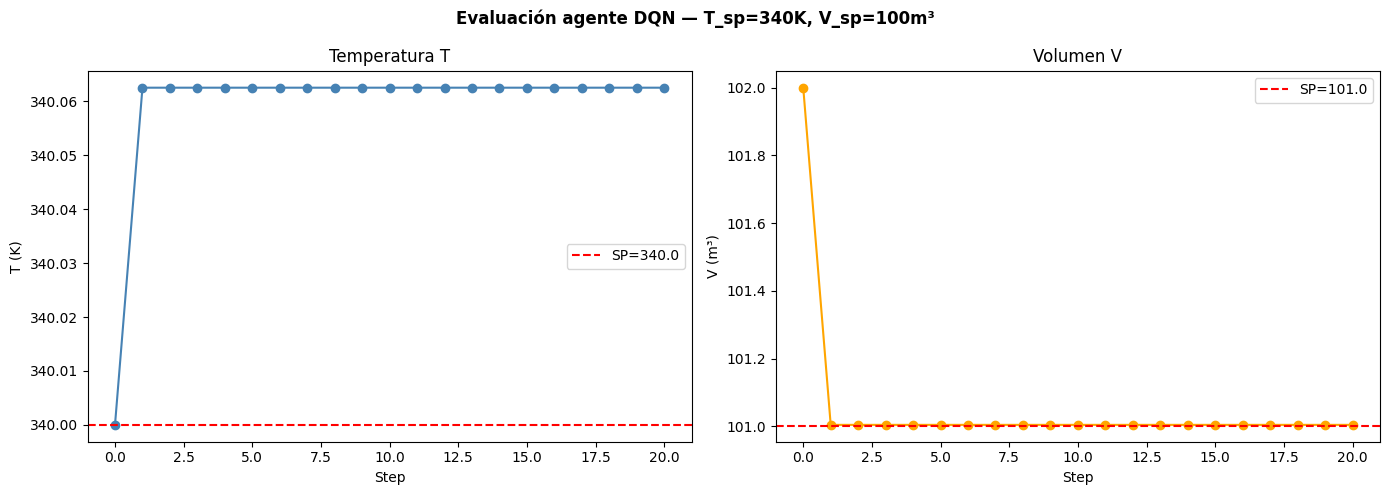

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(traj_T, marker='o', color='steelblue')
axes[0].axhline(T_sp, color='red', linestyle='--', label=f'SP={T_sp}')
axes[0].set_title('Temperatura T')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('T (K)')
axes[0].legend()

axes[1].plot(traj_V, marker='o', color='orange')
axes[1].axhline(V_sp, color='red', linestyle='--', label=f'SP={V_sp}')
axes[1].set_title('Volumen V')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('V (m³)')
axes[1].legend()

plt.suptitle('Evaluación agente DQN — T_sp=340K, V_sp=100m³', fontweight='bold')
plt.tight_layout()
plt.show()

## Pruebas con otros SP

In [ ]:
# ============ CARGAR AGENTE ============
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MANIPULABLE_RANGES = [(300, 420), (99.5, 104)]

PPO_CHECKPOINT = '/Users/gonzalo/Documents/valeria/MASTER/TESIS/PID_Agent/Version_4/Entrenamiento/CTRL/PPO/agent_ctrl_best.pt'

config = {
    'env_config': {
        'architecture'           : 'simple',
        'env_type'               : 'simulation',
        'action_type'            : 'continuous',
        'n_manipulable_vars'     : 2,
        'manipulable_ranges'     : MANIPULABLE_RANGES,
        'manipulable_setpoints'  : None,
        'dt_usuario'             : 1.0,
        'max_steps'              : 100,
        'max_time_detector'      : 60,
        'reward_dead_band'       : 0.02,
        'delta_percent_ctrl'     : 0.2,
        'reward_weights'         : {'error': 1.0, 'tiempo': 0.001, 'overshoot': 0.3, 'energy': 0.001},
        'pid_limits'             : [(0.01, 50.0), (0.001, 1.0), (0.0, 1.0)],
        'agent_controller_config': {'agent_type': 'continuous'},
        'env_type_config'        : {'dt': 1.0, 'control_limits': (MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1])},
        'stability_config'       : {
            'error_increase_tolerance': 2.0,
            'max_sign_changes_ratio'  : 0.3,
            'max_abrupt_change_ratio' : 0.05,
            'abrupt_change_threshold' : 0.2,
        },
    },
    'agent_ctrl_config': {
            'algorithm'      : 'ppo',
            'state_dim'      : 10,
            'action_dim'     : 6,
            'n_vars'         : 2,
            'action_type'    : 'continuous',
            'hidden_dims'    : (64, 32),
            'lr_actor'       : 1e-05,
            'lr_critic'      : 0.001,
            'gamma'          : 0.95,
            'gae_lambda'     : 0.95,
            'clip_epsilon'   : 0.3,
            'ppo_epochs'     : 20,
            'rollout_steps'  : 1024,
            'mini_batch_size': 128,
            'entropy_coef'   : 0.05,
            'value_coef'     : 0.25,
            'max_grad_norm'  : 0.5,
            'device'         : 'cuda' if torch.cuda.is_available() else 'cpu',
            'seed'           : SEED,
        },
    'n_episodes'   : 1,
    'use_wandb'    : False,
    'checkpoint_dir': 'checkpoints/eval_tmp',
}

cstr = CSTRSimulator(dt=1.0, control_limits=(MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1]))
trainer = PPTrainer(config)
trainer.env.proceso.connect_external_process(cstr)
trainer.agent_ctrl.load(PPO_CHECKPOINT)
print('Agente PPO cargado correctamente')

In [ ]:
# ============ GRILLA DE SETPOINTS ============
T_setpoints = [320, 340, 360, 380, 400]   # K
V_setpoints = [100.0, 101.0, 102.0]       # m³

# ============ FUNCIÓN DE EVALUACIÓN ============
def evaluar_sp(trainer, T_sp, V_sp, max_steps=100):
    """Corre un episodio con setpoints fijos y devuelve las trayectorias."""
    trainer.env.manipulable_setpoints = [T_sp, V_sp]
    state = trainer.env.reset()[0]

    T_hist, V_hist = [], []
    done = False
    step = 0

    while not done and step < max_steps:
        action = trainer.agent_ctrl.select_action(state, training=False)
        next_state, reward, terminated, truncated, info = trainer.env.step(action)
        done = terminated or truncated

        T_hist.append(trainer.env.manipulable_pvs[0])
        V_hist.append(trainer.env.manipulable_pvs[1])

        state = next_state
        step += 1

    return np.array(T_hist), np.array(V_hist)

In [ ]:
# ============ EVALUAR Y GRAFICAR ============
fig, axes = plt.subplots(
    len(T_setpoints), 2,
    figsize=(14, 4 * len(T_setpoints))
)

for i, T_sp in enumerate(T_setpoints):
    V_sp = 101.0  # V fijo para comparar el efecto de T

    T_hist, V_hist = evaluar_sp(trainer, T_sp, V_sp)
    steps = np.arange(1, len(T_hist) + 1)

    # --- Temperatura ---
    ax_T = axes[i, 0]
    ax_T.plot(steps, T_hist, color='steelblue', linewidth=2, label='T (PV)')
    ax_T.axhline(T_sp, color='red', linestyle='--', linewidth=1.5, label=f'SP={T_sp}K')
    ax_T.set_title(f'Temperatura — SP={T_sp}K, V_sp={V_sp}m³')
    ax_T.set_xlabel('Step')
    ax_T.set_ylabel('T (K)')
    ax_T.legend()
    ax_T.grid(True, alpha=0.3)

    # --- Volumen ---
    ax_V = axes[i, 1]
    ax_V.plot(steps, V_hist, color='orange', linewidth=2, label='V (PV)')
    ax_V.axhline(V_sp, color='red', linestyle='--', linewidth=1.5, label=f'SP={V_sp}m³')
    ax_V.set_title(f'Volumen — SP={T_sp}K, V_sp={V_sp}m³')
    ax_V.set_xlabel('Step')
    ax_V.set_ylabel('V (m³)')
    ax_V.legend()
    ax_V.grid(True, alpha=0.3)

    T_final = T_hist[-1]
    V_final = V_hist[-1]
    print(f'T_sp={T_sp}K → T_final={T_final:.2f}K (error={abs(T_final-T_sp):.2f}K) | '
          f'V_final={V_final:.3f}m³ (error={abs(V_final-V_sp):.4f}m³)')

plt.suptitle('Evaluación PPO CTRL — Distintos Setpoints de T', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eval_ppo_ctrl_T_setpoints.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============ TAMBIÉN VARIAR V ============
fig, axes = plt.subplots(
    len(V_setpoints), 2,
    figsize=(14, 4 * len(V_setpoints))
)

T_sp_fijo = 340.0  # T fija para comparar el efecto de V

for i, V_sp in enumerate(V_setpoints):
    T_hist, V_hist = evaluar_sp(trainer, T_sp_fijo, V_sp)
    steps = np.arange(1, len(T_hist) + 1)

    ax_T = axes[i, 0]
    ax_T.plot(steps, T_hist, color='steelblue', linewidth=2)
    ax_T.axhline(T_sp_fijo, color='red', linestyle='--', linewidth=1.5, label=f'SP={T_sp_fijo}K')
    ax_T.set_title(f'Temperatura — T_sp={T_sp_fijo}K, V_sp={V_sp}m³')
    ax_T.set_xlabel('Step')
    ax_T.set_ylabel('T (K)')
    ax_T.legend()
    ax_T.grid(True, alpha=0.3)

    ax_V = axes[i, 1]
    ax_V.plot(steps, V_hist, color='orange', linewidth=2)
    ax_V.axhline(V_sp, color='red', linestyle='--', linewidth=1.5, label=f'SP={V_sp}m³')
    ax_V.set_title(f'Volumen — T_sp={T_sp_fijo}K, V_sp={V_sp}m³')
    ax_V.set_xlabel('Step')
    ax_V.set_ylabel('V (m³)')
    ax_V.legend()
    ax_V.grid(True, alpha=0.3)

    T_final = T_hist[-1]
    V_final = V_hist[-1]
    print(f'V_sp={V_sp}m³ → V_final={V_final:.3f}m³ (error={abs(V_final-V_sp):.4f}m³) | '
          f'T_final={T_final:.2f}K (error={abs(T_final-T_sp_fijo):.2f}K)')

plt.suptitle('Evaluación PPO CTRL — Distintos Setpoints de V', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eval_ppo_ctrl_V_setpoints.png', dpi=150, bbox_inches='tight')
plt.show()